## Exploratory Data Analysis & Feature Engineering

### 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

### 2. Load Dataset

In [3]:
df = pd.read_csv("cleaned_dataset_role01.csv")

print("Shape:", df.shape)

Shape: (2717, 78)


### 3. Basic Overview

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2717 entries, 0 to 2716
Data columns (total 78 columns):
 #   Column                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      Non-Null Count  Dtype  
---  ------                    

### 4. Missing Values

In [5]:
df.isnull().sum()

#                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          0
By agreeing to take part in this survey, you confirm that you have read, understood and agreed with the following statements. Please note t

### 5. Statistic Of The Data

In [6]:
df.dtypes.value_counts()

str        37
float64    33
int64       8
Name: count, dtype: int64

In [7]:
df["food_security_score"].describe()

count    2717.000000
mean        1.993375
std         2.646995
min         0.000000
25%         0.000000
50%         0.000000
75%         4.000000
max         8.000000
Name: food_security_score, dtype: float64

In [8]:
df["child_security_score"].describe()

count    2717.000000
mean        0.316894
std         0.960975
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         7.000000
Name: child_security_score, dtype: float64

In [9]:
df["fuel_security_score"].describe()

count    2717.000000
mean        0.807508
std         1.421009
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         7.000000
Name: fuel_security_score, dtype: float64

In [10]:
df["food_security_label"].value_counts()

food_security_label
High        1411
Very Low     454
Marginal     438
Low          414
Name: count, dtype: int64

In [11]:
df["fuel_security_label"].value_counts()

fuel_security_label
Secure           1766
Moderate Risk     606
High Risk         345
Name: count, dtype: int64

In [12]:
df["child_security_label"].value_counts()

child_security_label
High        2352
Low          218
Marginal     118
Very Low      29
Name: count, dtype: int64

### 6. Target Label Distribution

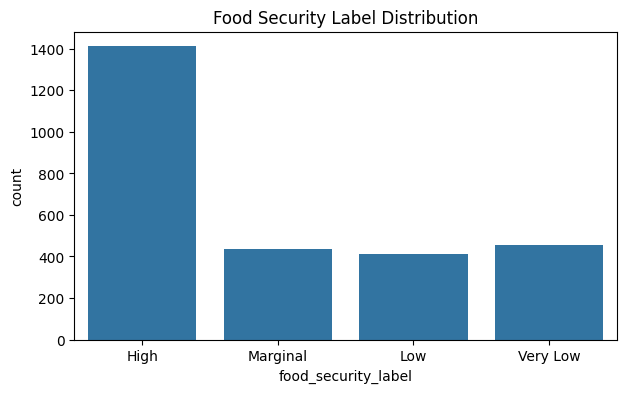

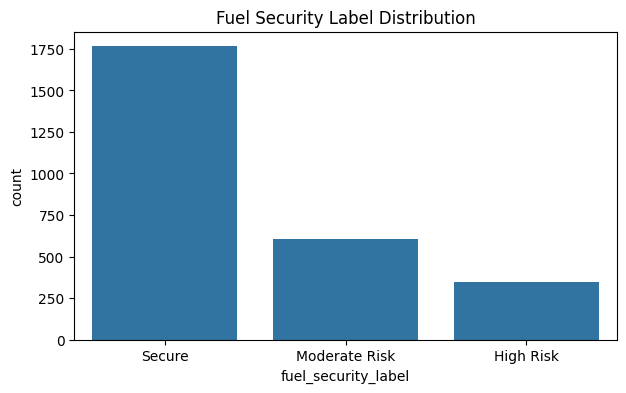

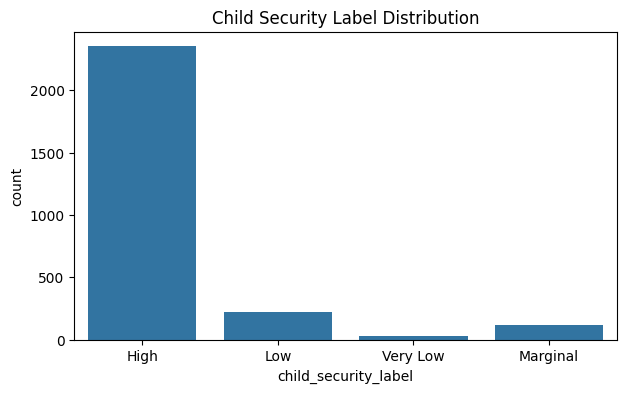

In [13]:
targets = ["food_security_label", "fuel_security_label", "child_security_label"]

for col in targets:
    if col in df.columns:
        plt.figure(figsize=(7, 4))
        sns.countplot(data=df, x=col)
        plt.title(f"{" ".join(col.split("_")).title()} Distribution")
        plt.show()

### 7. Score Distribution

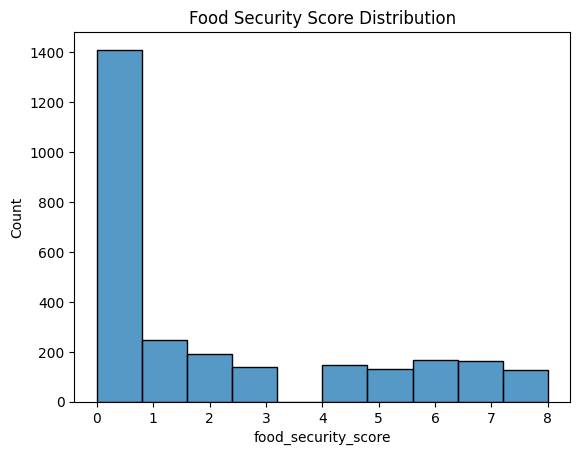

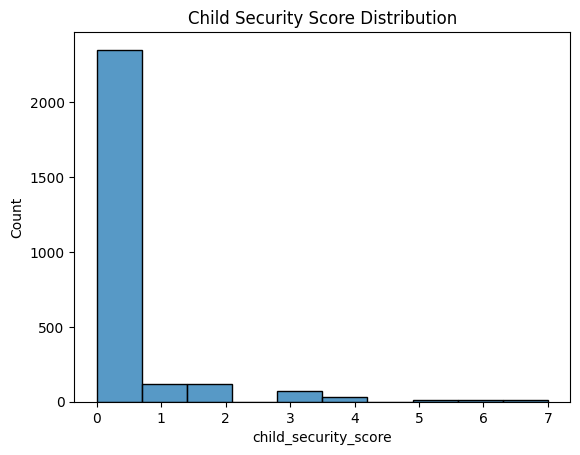

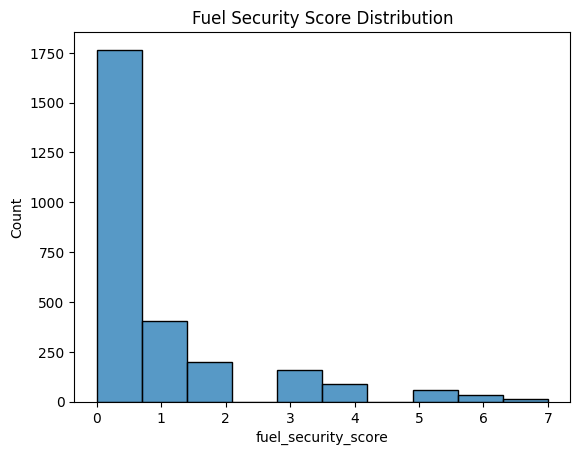

In [14]:
score = ["food_security_score", "child_security_score", "fuel_security_score"]

for i in score:
    sns.histplot(df[i], bins=10)
    plt.title(f"{" ".join(i.split("_")).title()} Distribution")
    plt.show()

### 8. Crosstab Example

In [15]:
pd.crosstab(
    df["What is your annual household income before tax?"], df["food_security_label"]
)

food_security_label,High,Low,Marginal,Very Low
What is your annual household income before tax?,,,,
"Less than £14,900 p.a.",74,111,89,190
"More than £58,900 p.a.",569,22,44,8
Prefer not to say,239,78,84,69
"£14,901- £24,300 p.a.",107,71,77,97
"£24,301- £37,900 p.a.",195,88,76,65
"£37,901- £58,900 p.a.",227,44,68,25


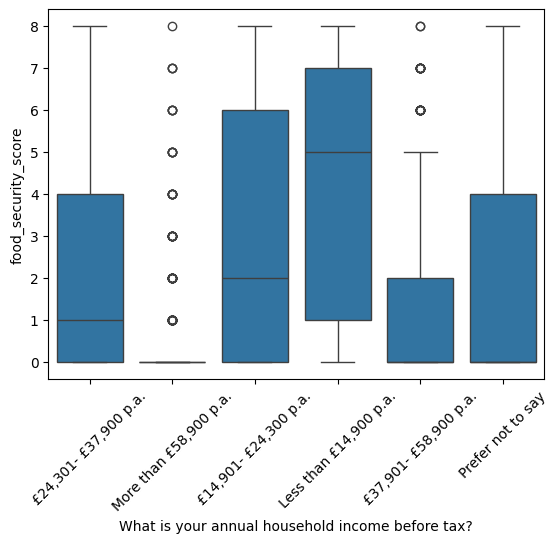

In [16]:
sns.boxplot(
    x="What is your annual household income before tax?",
    y="food_security_score",
    data=df,
)
plt.xticks(rotation=45)
plt.show()

#### 9. Demographic EDA

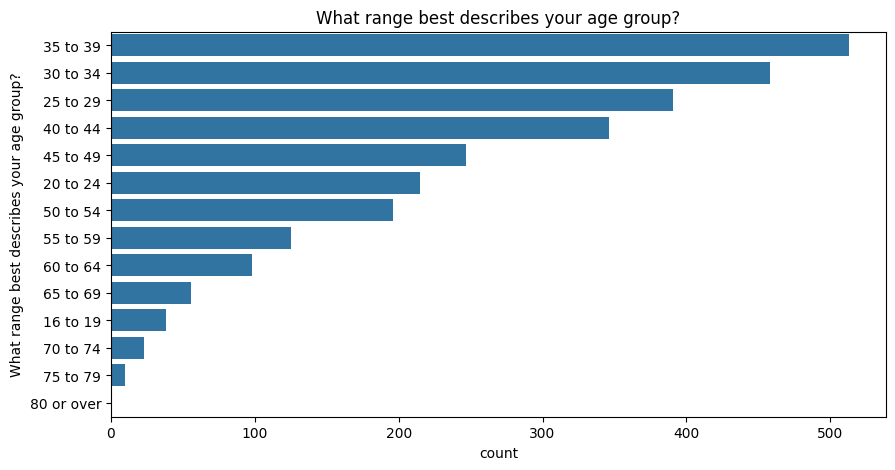

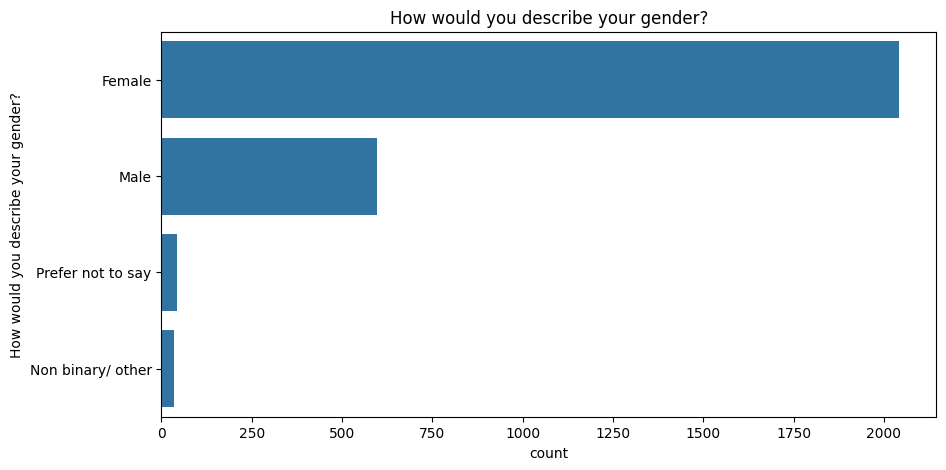

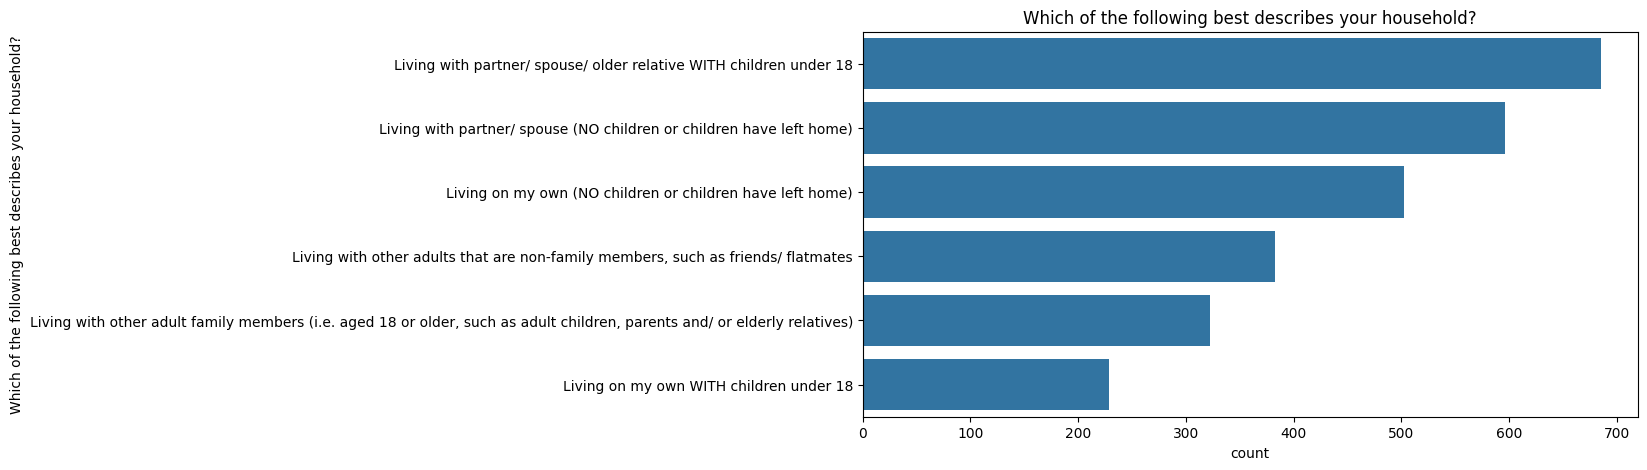

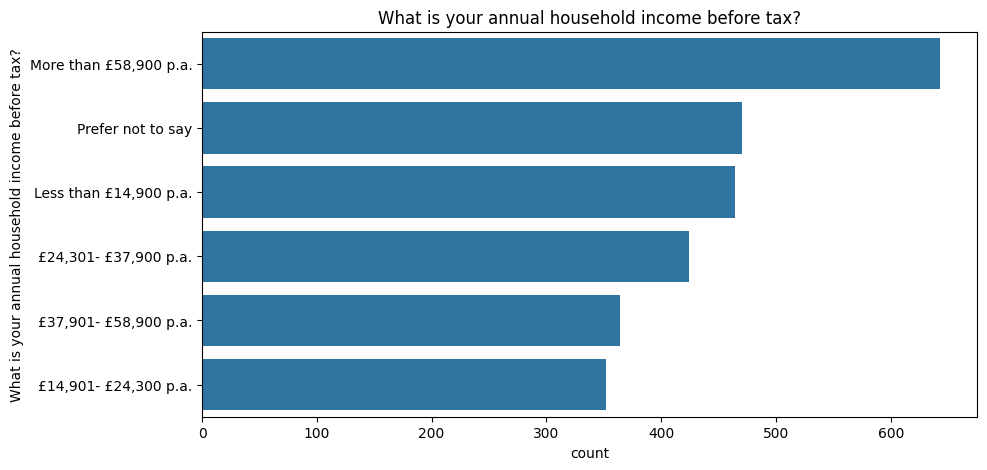

In [17]:
eda_cols = [
    "What range best describes your age group?",
    "How would you describe your gender?",
    "Which of the following best describes your household?",
    "What is your annual household income before tax?",
]

for col in eda_cols:
    if col in df.columns:
        plt.figure(figsize=(10, 5))
        sns.countplot(data=df, y=col, order=df[col].value_counts().index)
        plt.title(col)
        plt.show()

## FEATURE ENGINEERING

### Income Risk Group

#### What is this?

A new feature that classifies households into two groups:

- **1 = Low-income risk**
- **0 = Not low-income risk / Higher income**

**Example:**

- Less than **£20,000** → **1**
- Above **£20,000** → **0**

---

#### Why do we use this?

Income is one of the strongest factors linked to:

- Food insecurity  
- Fuel poverty  
- Child hardship  

Instead of using many separate income categories, we simplify them into a binary risk group.

---

#### What is the impact of this?

- Reduces noise caused by multiple income categories  
- Makes it easier for the model to learn poverty-related patterns  
- Acts as a strong predictor of hardship  

---

#### What do we achieve?

- Better model understanding  
- Improved accuracy  
- Easier interpretation of results

In [18]:
low_income_groups = ["Less than £10,000", "£10,000 - £19,999"]


df["income_risk_group"] = (
    df["What is your annual household income before tax?"]
    .isin(low_income_groups)
    .astype(int)
)

### Employment Risk Score

#### What is this?

A score created from household employment status to represent economic risk.

**Example Logic:**

- **Unemployed** → High risk  
- **Part-time employed** → Medium risk  
- **Full-time employed** → Lower risk  

---

#### Why do we use this?

Employment status directly affects:

- Regular income  
- Ability to pay bills  
- Food affordability  

Instead of using separate employment categories, one score captures overall job stability.

---

#### What is the impact of this?

- Combines multiple employment types into one useful feature  
- Helps the model understand economic vulnerability  
- Reduces complexity from separate columns  

---

#### What do we achieve?

- Stronger economic signal  
- Better prediction power  
- Simpler feature set

In [19]:
employment_cols = [
    "Working full-time",
    "Working part-time",
    "Unemployed",
    "Retired",
    "Student",
]

# ensure columns exist
for col in employment_cols:
    if col not in df.columns:
        df[col] = 0

# convert to numeric binary
for col in employment_cols:
    df[col] = df[col].replace(
        {"Yes": 1, "No": 0, "Selected": 1, "Not Selected": 0, True: 1, False: 0}
    )

    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# create employment risk
df["employment_risk"] = (
    df["Unemployed"] * 3
    + df["Student"] * 1
    + df["Working part-time"] * 1
    + df["Retired"] * 1
    - df["Working full-time"] * 2
)

### Social Support Score

####  What is this?

A feature that counts the number of support sources available to a person, such as:

- Foodbank  
- Family  
- Community group  
- Neighbours  

---

####  Why do we use this?

People with stronger support networks may cope better during hardship and financial stress.

---

####  What is the impact of this?

- Higher support scores may reduce crisis severity  
- Helps identify hidden resilience in households  

---

####  What do we achieve?

- Captures hidden resilience  
- Improves real-world prediction  
- Adds social context beyond income  

In [20]:
support_cols = [
    "Foodbank",
    "Community or faith group",
    "Close family or friends",
    "Neighbours",
]

for col in support_cols:
    if col not in df.columns:
        df[col] = 0

support_map = {"Yes": 1, "No": 0, "Selected": 1, "Not Selected": 0, True: 1, False: 0}

for col in support_cols:
    df[col] = df[col].replace(support_map)
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
    df[col] = (df[col] > 0).astype(int)

df["social_support_score"] = df[support_cols].sum(axis=1).astype(int)

### Isolation Score

####  What is this?

A numeric score created from loneliness or isolation responses.

**Example:**

- Never = 0  
- Rarely = 1  
- Sometimes = 2  
- Often = 3  
- Always = 4  

---

####  Why do we use this?

Isolation is linked with:

- Mental stress  
- Reduced access to help  
- Financial hardship  

---

####  What is the impact of this?

Converts text-based wellbeing responses into measurable risk levels.

---

####  What do we achieve?

- Better use of wellbeing data  
- Stronger machine learning input  
- Captures emotional vulnerability  


In [21]:
iso_map = {"Never": 0, "Rarely": 1, "Sometimes": 2, "Often": 3, "Always": 4}

iso_col = "How often do you feel isolated from others or left out?"

if iso_col in df.columns:
    df["isolation_score"] = df[iso_col].map(iso_map).fillna(0)

### Health Risk

####  What is this?

A binary feature:

- Yes, health limitation = 1  
- No = 0  

---

####  Why do we use this?

Poor physical or mental health can reduce:

- Work ability  
- Income stability  
- Energy tolerance  
- Household resilience  

---

####  What is the impact of this?

Helps predict households experiencing pressure and hardship.

---

####  What do we achieve?

- Adds vulnerability signal  
- Better food and fuel prediction  
- Better fairness in analysis  


In [22]:
health_col = "Do you have any physical or mental health conditions or illnesses that are limiting your day to day activities?"

if health_col in df.columns:
    df["health_risk"] = df[health_col].map({"Yes": 1, "No": 0}).fillna(0)

### Fuel Specific Features

#### Prepay Meter Risk

####  What is this?

A binary feature:

- Uses prepayment meter = 1  
- No = 0  

---

####  Why do we use this?

Prepayment meter users often face:

- Higher energy costs  
- Self-disconnection risk  
- Fuel poverty  

---

####  What is the impact of this?

Highly useful for predicting fuel poverty risk.

---

####  What do we achieve?

- Strong fuel hardship indicator  
- Better energy-risk modelling 

In [23]:
meter_col = (
    "Do you use a prepayment or pay-as-you-go meter to pay for your energy usage?"
)

if meter_col in df.columns:
    df["prepay_meter_risk"] = df[meter_col].map({"Yes": 1, "No": 0}).fillna(0)

else:
    df["prepay_meter_risk"] = 0

#### Fuel Vulnerability Score

####  What is this?

A combined risk score using:

- Low income  
- Health risk  
- Prepayment meter usage  

---

####  Why do we use this?

Fuel poverty often results from multiple risks combined rather than one factor alone.

---

####  What is the impact of this?

Captures compound hardship more effectively.

---

####  What do we achieve?

- Better than using single variables separately  
- Stronger fuel model accuracy  
- More realistic social risk score  



In [24]:
df["fuel_vulnerability_score"] = (
    df["income_risk_group"] + df["health_risk"] + df["prepay_meter_risk"]
)

#### Interaction Features

#### Income Unemployed Interaction

####  What is this?

An interaction feature:

- low_income × unemployed  

---

####  Why do we use this?

Low income alone is a risk.  
Unemployment alone is a risk.  
Together, they create much higher economic pressure.

---

####  What is the impact of this?

Captures combined financial hardship.

---

####  What do we achieve?

- Helps model learn severe hardship cases  
- Better food and child hardship predictions  


In [25]:
df["income_unemployed_interaction"] = df["income_risk_group"] * df["Unemployed"]

#### Medical Heat Risk

####  What is this?

An interaction feature:

- health_risk × prepay_meter_risk  

---

####  Why do we use this?

A person with health issues and expensive heating risk is highly vulnerable.

---

####  What is the impact of this?

Useful for predicting fuel poverty and cold-home risk.

---

####  What do we achieve?

- Detects high-risk households  
- Better welfare targeting  
- Better fuel hardship prediction  


In [26]:
df["medical_heat_risk"] = df["health_risk"] * df["prepay_meter_risk"]

#### Conclusion:- Overall Why Feature Engineering Was Important

####  Why did we use these features?

Raw survey data is often scattered and noisy.  
Feature engineering transforms raw responses into meaningful risk indicators.

---

####  Overall Impact

- Better model performance  
- Better interpretation  
- More realistic household hardship prediction  

---

####  What We Achieved

- Reduced noise  
- Improved prediction accuracy  
- Easier explanations  
- Stronger dissertation quality  
- More policy-relevant insights

## Define Feature Sets for Each Domain

#### Base features

In [27]:
base_features = [
    "Working full-time",
    "Working part-time",
    "Unemployed",
    "Retired",
    "Student",
    "Other",
    "incentivised",
    "Foodbank",
    "Community or faith group",
    "Close family or friends",
    "Neighbours",
]

#### Extra Candidate Features

In [28]:
food_extra_candidates = [
    "What is your annual household income before tax?",
    "Which of the following best describes your household?",
    "What range best describes your age group?",
    "How would you describe your gender?",
    "In general, how satisfied are you with your life?",
    "Do you have any physical or mental health conditions or illnesses that are limiting your day to day activities?",
    "How often do you feel isolated from others or left out?",
]

fuel_extra_candidates = [
    "What is your annual household income before tax?",
    "Which of the following best describes the house you currently live in?",
    "Do you know the Energy Performance Certificate (EPC) rating for the house you currently live in?",
    "Do you use a prepayment or pay-as-you-go meter to pay for your energy usage?",
    "Which of the following best describes your household?",
    "What range best describes your age group?",
    "Consider your grocery shopping habits in the past 12 months. How often have you avoided food that requires cooking to reduce energy usage?",
]

child_extra_candidates = [
    "What is your annual household income before tax?",
    "Which of the following best describes your household?",
    "What range best describes your age group?",
    "How would you describe your gender?",
]

#### Engineered Features

In [29]:
engineered_features = [
    "income_risk_group",
    "employment_risk",
    "social_support_score",
    "isolation_score",
    "health_risk",
    "prepay_meter_risk",
    "fuel_vulnerability_score",
    "income_unemployed_interaction",
    "medical_heat_risk",
]

In [30]:
def get_valid_features(feature_list):
    return [col for col in feature_list if col in df.columns]

# Final Feature Selection

## Food Features

### Removed Features

The following features were removed from the food prediction model:

- `prepay_meter_risk`
- `fuel_vulnerability_score`
- `medical_heat_risk`
- `income_unemployed_interaction`
- Duplicate raw support columns (retained only the support score)

---

### Why were these removed?

These features were either:

- More relevant to fuel poverty than food hardship  
- Redundant after feature engineering  
- Duplicate information already captured in summary scores  

---

### What was the benefit?

- Reduced unnecessary model complexity  
- Lowered noise in the dataset  
- Improved focus on food-related predictors  
- Better model efficiency and interpretability

In [31]:
food_features = get_valid_features(
    ["Working full-time", "Working part-time", "Unemployed", "Retired", "incentivised"]
    + [
        "What is your annual household income before tax?",
        "Which of the following best describes your household?",
        "What range best describes your age group?",
        "How would you describe your gender?",
        "In general, how satisfied are you with your life?",
        "Do you have any physical or mental health conditions or illnesses that are limiting your day to day activities?",
        "How often do you feel isolated from others or left out?",
    ]
    + [
        "income_risk_group",
        "employment_risk",
        "social_support_score",
        "isolation_score",
        "health_risk",
    ]
)

# FUEL FEATURES
### Keep fuel related engineered features

In [32]:
fuel_features = get_valid_features(
    ["Working full-time", "Working part-time", "Unemployed", "Retired", "incentivised"]
    + [
        "What is your annual household income before tax?",
        "Which of the following best describes the house you currently live in?",
        "Do you know the Energy Performance Certificate (EPC) rating for the house you currently live in?",
        "Do you use a prepayment or pay-as-you-go meter to pay for your energy usage?",
        "Which of the following best describes your household?",
        "What range best describes your age group?",
        "Consider your grocery shopping habits in the past 12 months. How often have you avoided food that requires cooking to reduce energy usage?",
    ]
    + [
        "income_risk_group",
        "employment_risk",
        "health_risk",
        "prepay_meter_risk",
        "fuel_vulnerability_score",
        "medical_heat_risk",
    ]
)

# CHILD FEATURES
### Focus on household + income + employment

In [33]:
child_features = get_valid_features(
    [
        "Working full-time",
        "Working part-time",
        "Unemployed",
        "Retired",
        "Student",
        "incentivised",
    ]
    + [
        "What is your annual household income before tax?",
        "Which of the following best describes your household?",
        "What range best describes your age group?",
        "How would you describe your gender?",
    ]
    + [
        "income_risk_group",
        "employment_risk",
        "social_support_score",
        "health_risk",
        "income_unemployed_interaction",
    ]
)

In [34]:
print("Food Features :", len(food_features))
print("Fuel Features :", len(fuel_features))
print("Child Features:", len(child_features))

Food Features : 17
Fuel Features : 18
Child Features: 15


### Remove Features That Have not helpfull for the training

#### Import Libraries

In [35]:
import os
import json
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier

#### Function: Select Important Features using XGBoost

In [36]:
def select_features_xgb(
    df, feature_list, target_col, threshold=0.01, module_name=None, top_n=20
):
    valid_features = [c for c in feature_list if c in df.columns]

    X = df[valid_features].copy()
    y = df[target_col].copy()

    mask = y.notna()
    X = X.loc[mask].copy()
    y = y.loc[mask].astype(str)

    le = LabelEncoder()
    y = le.fit_transform(y)

    num_cols = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    y_series = pd.Series(y)
    can_stratify = (y_series.nunique() > 1) and (y_series.value_counts().min() >= 2)
    stratify_y = y if can_stratify else None

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=stratify_y
    )

    X_train = preprocessor.fit_transform(X_train_raw)
    _ = preprocessor.transform(X_test_raw)

    n_classes = y_series.nunique()
    model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="mlogloss" if n_classes > 2 else "logloss",
    )
    model.fit(X_train, y_train)

    feature_names = preprocessor.get_feature_names_out()
    importance_df = pd.DataFrame(
        {"Feature": feature_names, "Importance": model.feature_importances_}
    ).sort_values(by="Importance", ascending=False)

    selected_encoded = importance_df.loc[
        importance_df["Importance"] >= threshold, "Feature"
    ].tolist()

    original_selected = []
    for col in valid_features:
        if (col in selected_encoded) or any(
            f.startswith(f"{col}_") for f in selected_encoded
        ):
            original_selected.append(col)

    # NEW: plot feature importance
    if module_name:
        plot_df = importance_df.head(top_n)
        plt.figure(figsize=(10, max(4, int(top_n * 0.35))))
        sns.barplot(data=plot_df, x="Importance", y="Feature", orient="h")
        plt.title(f"{module_name} - Top {top_n} Feature Importances (XGBoost)")
        plt.tight_layout()
        plt.show()

    return original_selected, importance_df

### Domain Wise Feature Selection

C:\Users\DELL\AppData\Local\Temp\ipykernel_12048\3861410836.py:73: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


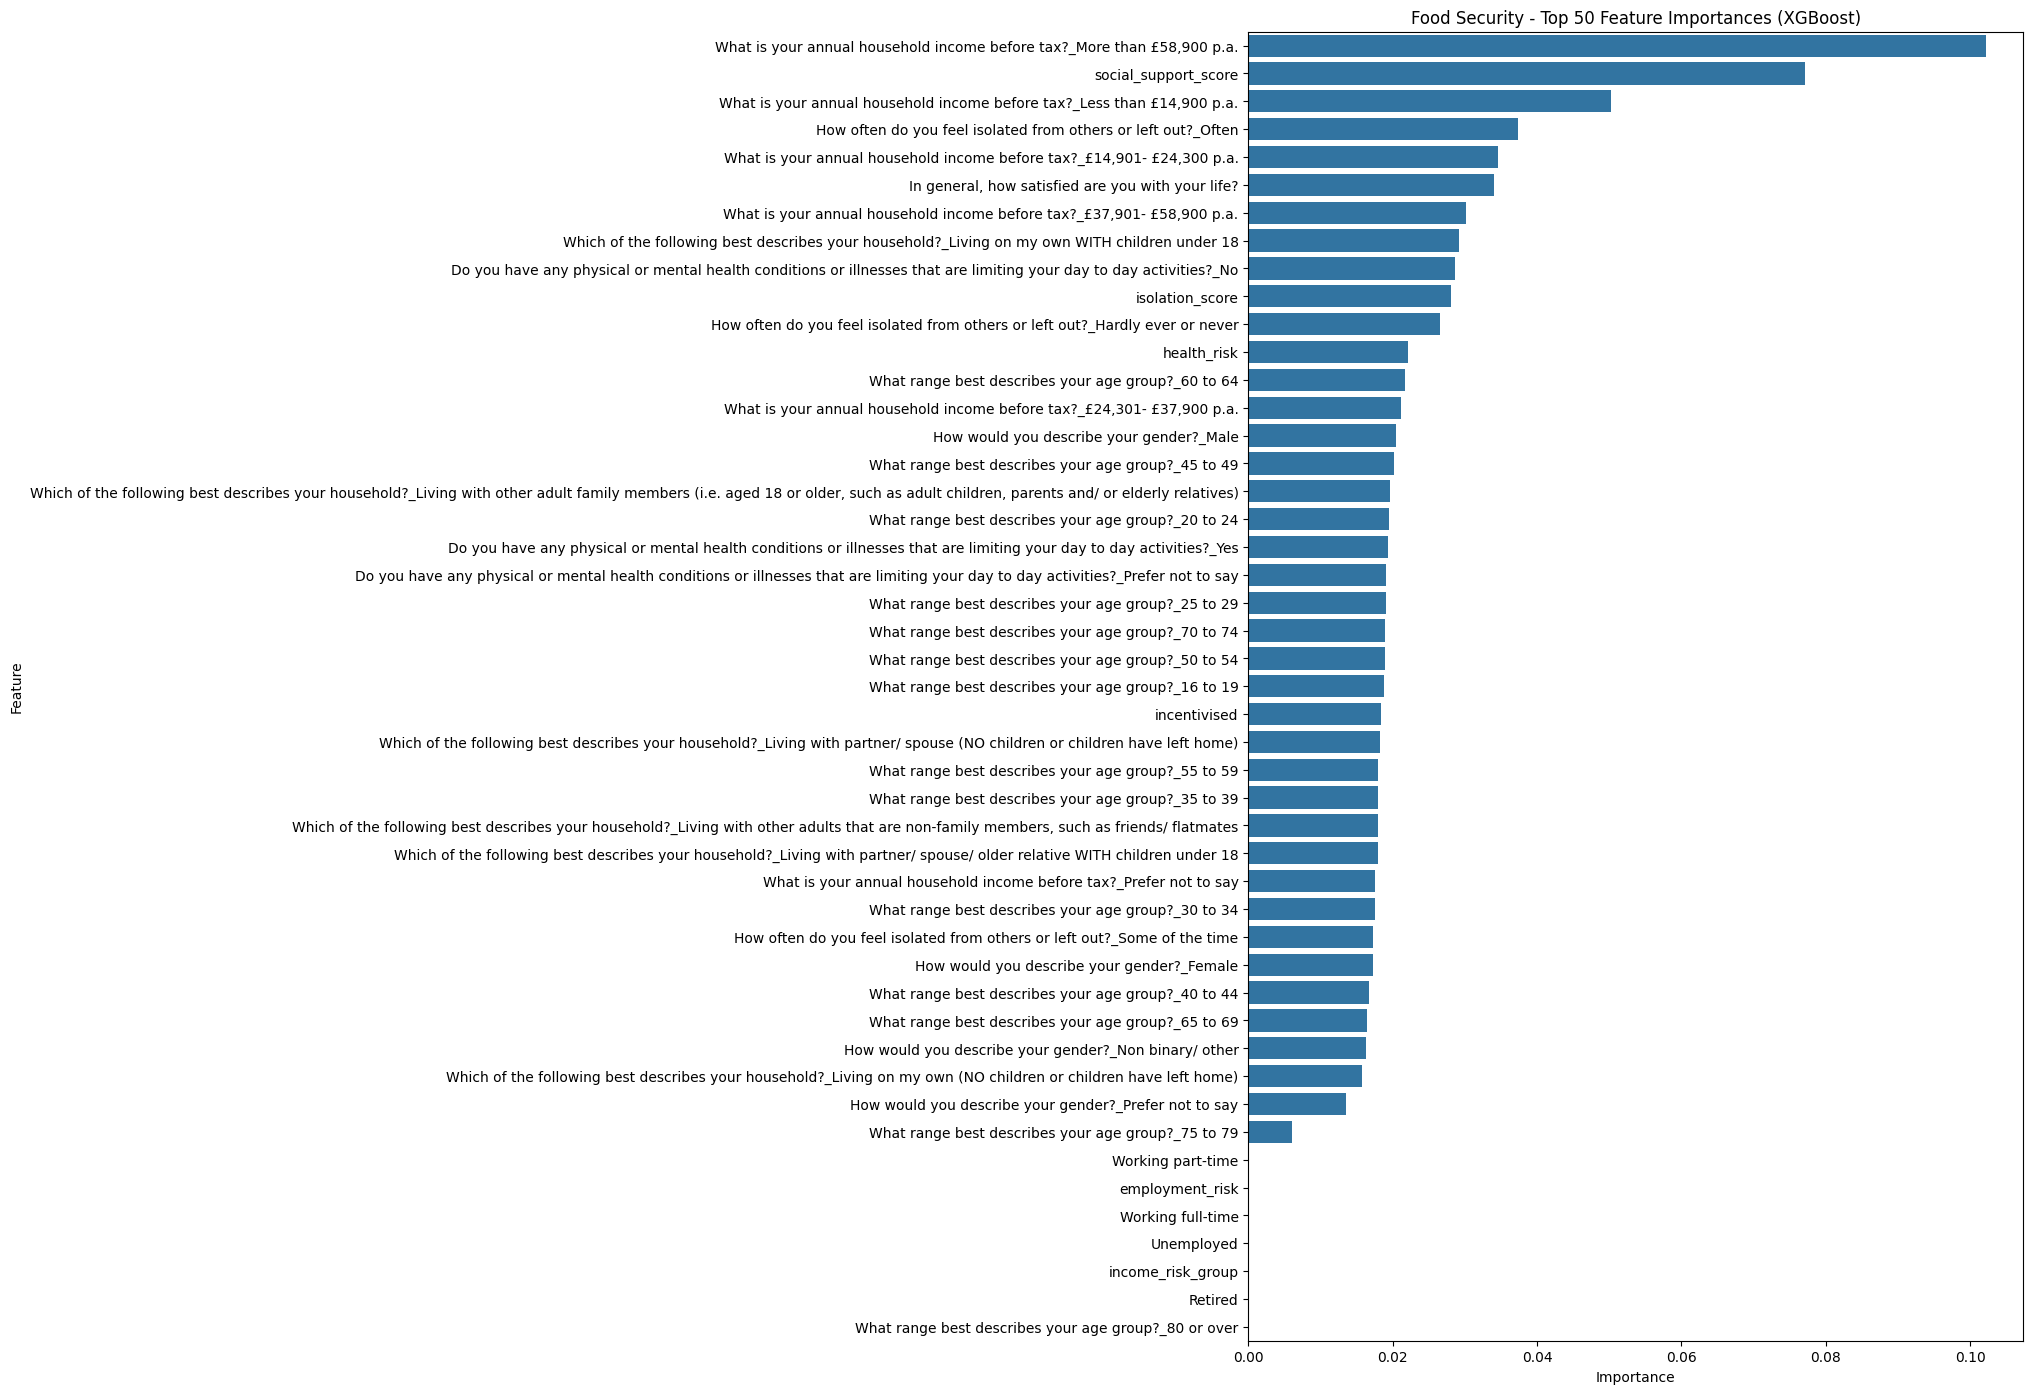

In [37]:
food_selected, food_imp = select_features_xgb(
    df,
    food_features,
    "food_security_label",
    top_n=50,
    module_name="Food Security",
    threshold=0.02,
)

C:\Users\DELL\AppData\Local\Temp\ipykernel_12048\3861410836.py:73: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


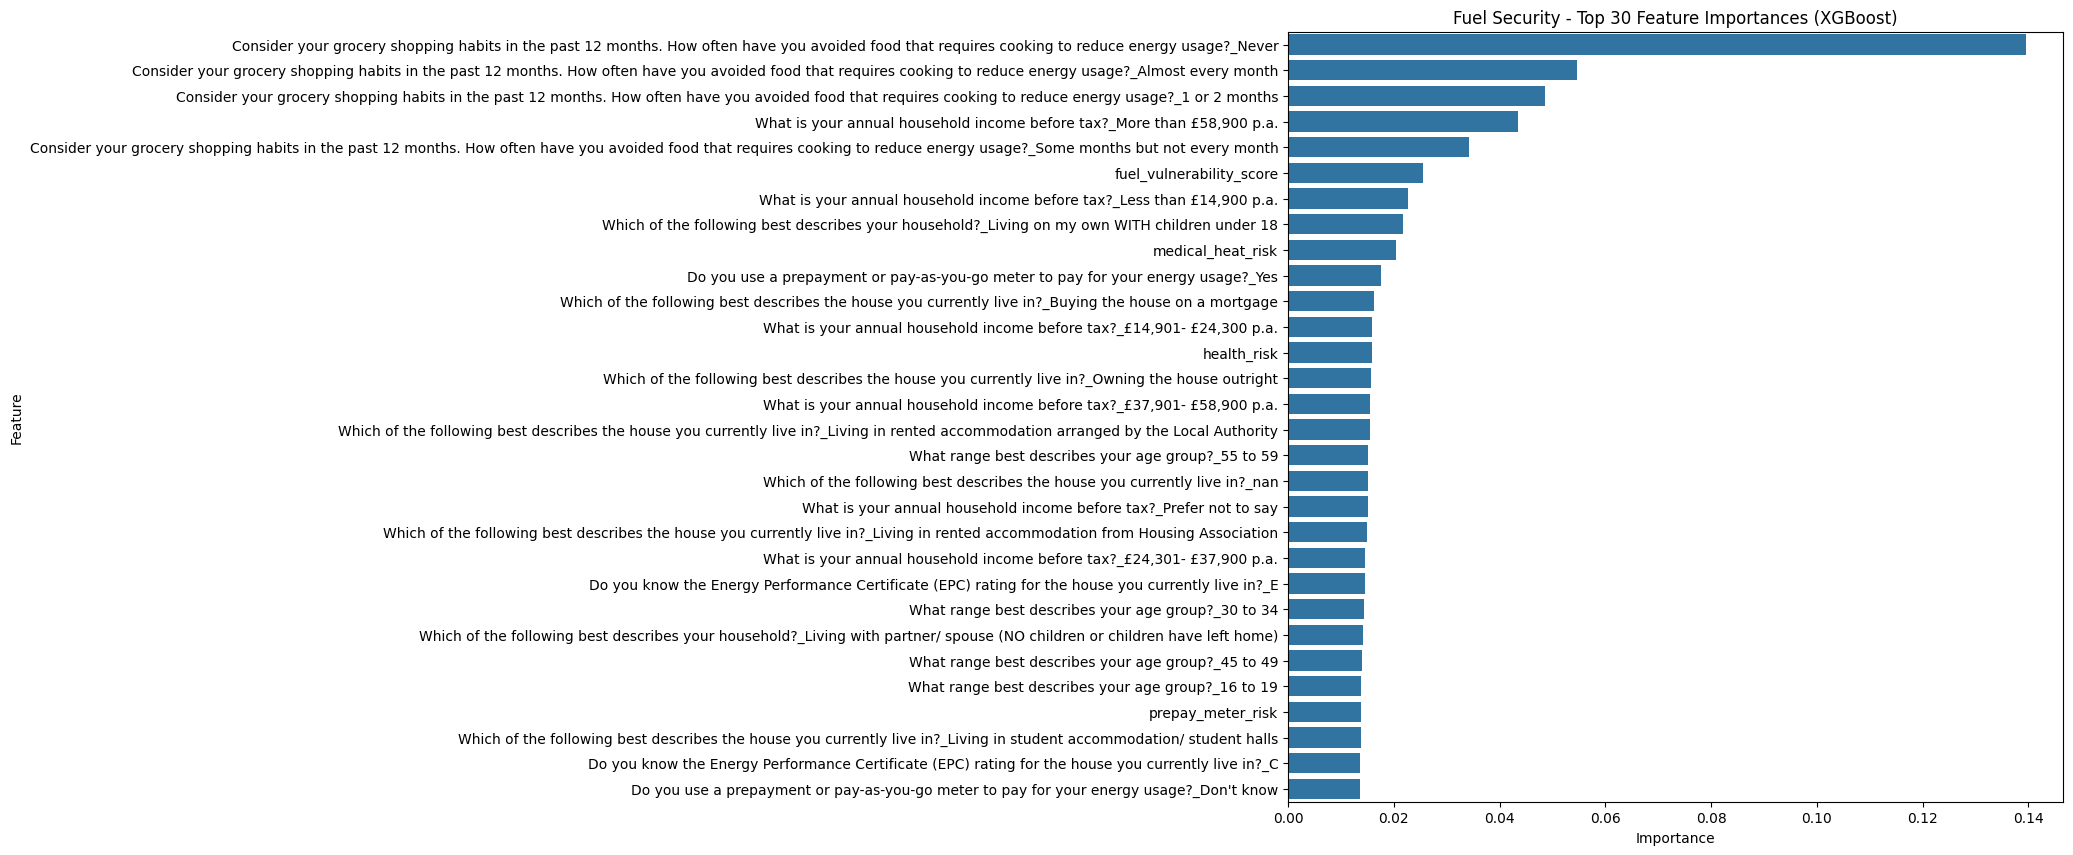

In [38]:
fuel_selected, fuel_imp = select_features_xgb(
    df, fuel_features, "fuel_security_label", top_n=30, module_name="Fuel Security",threshold=0.02,
)

C:\Users\DELL\AppData\Local\Temp\ipykernel_12048\3861410836.py:73: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


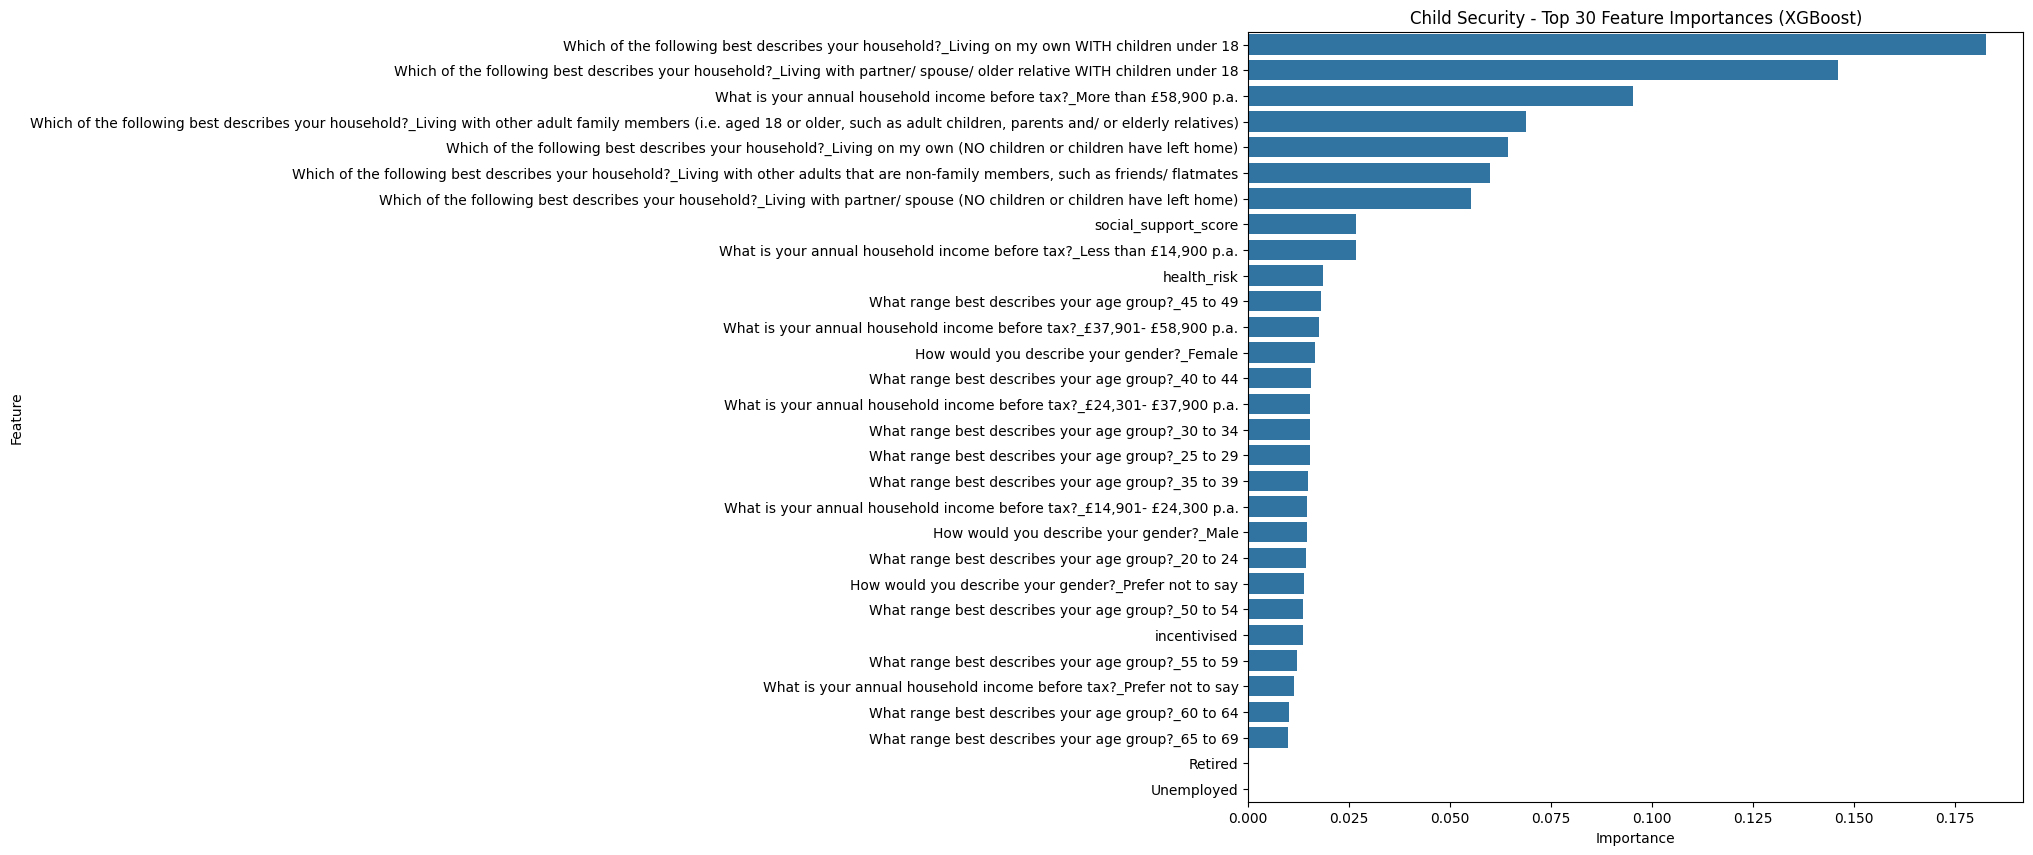

In [39]:
child_selected, child_imp = select_features_xgb(
    df,
    child_features,
    "child_security_label",
    top_n=30,
    module_name="Child Security",
)

#### Save Features 

In [40]:
os.makedirs("dataset", exist_ok=True)

with open("./dataset/food_features.json", "w") as f:
    json.dump(food_selected, f)

with open("./dataset/fuel_features.json", "w") as f:
    json.dump(fuel_selected, f)

with open("./dataset/child_features.json", "w") as f:
    json.dump(child_selected, f)

df.to_csv("./dataset/feature_engineered_data.csv", index=False)
print("Saved: feature_engineered_data.csv")

Saved: feature_engineered_data.csv
